In [1]:
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd

from mmkin import KineticsSeries, mm, fit_mm, mm_dimer, fit_mm_dimer, mm_third_order, fit_mm_third_order


/opt/homebrew/Caskroom/miniforge/base/lib/python3.10/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [2]:
mutants = ['wt', 'N214A', 'Q256A', 'S284A']
mutant_colors  = ['k', 'b', 'purple', 'teal']
mutant_markers = ["o", "v", "s", "D"]

KDs = [1.8, 14.93, 3.1, 1.6]

ks_s = [
        KineticsSeries('./wt/wt.yaml', corrections='./config.yaml', prefix='./wt'),
        KineticsSeries('./N214A/n214a.yaml', corrections='./config.yaml', prefix='./N214A'),
        KineticsSeries('./Q256A/q256a.yaml', corrections='./config.yaml', prefix='./Q256A'),
        KineticsSeries('./S284A/s284a.yaml', corrections='./config.yaml', prefix='./S284A'),
       ]

normal_ps = [10.0, 20.0, 40.0, 80.0, 160.0]
ss = np.array([320.0, 160.0, 80.0, 40.0, 20.0, 10.0, 5.0])

# N214A experiments were performed to higher final concentration
n214a_ps = [10.0, 20.0, 40.0, 80.0, 160.0, 320.0, 640.0, 1280.0]


Loading: 210401_2µM_MproWT.csv...
 ... excluded
Loading: 210401_buffer_200µM_MproWT.csv...
 ... excluded
Loading: 210413_02_002µM_MproWT.csv...
 ... excluded
Loading: 210413_buffer_2µM_MproWT.csv...
 ... excluded
Loading: 210420_20µM_MproWT.csv...
 ... excluded
Loading: 210420_10µM_MproWT.csv...
 ... excluded
Loading: 210420_5_and_2µM_MproWT.csv...
 ... excluded
Loading: 210430_20_10_5_and_2µM_MproWT.csv...
Loading: 210430_buffer_160_80_and_40µM_MproWT.csv...
Loading: 210507_buffer_20µM_MproWT_N_Q_S.csv...
 ... excluded
Loading: 210507_10µM_MproWT_N_Q_S.csv...
 ... excluded
Loading: 210414_20_2_02_002µM_MproN214A.csv...
 ... excluded
Loading: 210421_20_and_10_µM_MproN214A.csv...
 ... excluded
Loading: 210421_5_and_2_µM_MproN214A.csv...
 ... excluded
Loading: 210427_buffer_160_and_80µM_MproN214A.csv...
 ... excluded
Loading: 210427_buffer_160_and_80µM_MproN214A_2.csv...
 ... excluded
Loading: 210427_40_20_and_10µM_MproN214A.csv...
 ... excluding E=20.00 / S=20.00
 ... excluding E=10.00 

In [3]:
for ks in ks_s:
    ks.fit_v0(r2_threshold=0.0)

In [4]:
# write v0 data to excel
with pd.ExcelWriter('fit_velocities.xlsx') as writer:
    for ik, ks in enumerate(ks_s):
        mutant_name = mutants[ik]
        df = pd.DataFrame(ks.get_fit_v0_as_json())
        df = df.sort_values(by=['[E] (µM)', '[S] (µM)']).reset_index(drop=True)
        df.to_excel(writer, sheet_name=mutant_name, index=False)

In [5]:
colormap = plt.get_cmap('plasma_r')

def set_color(concentration):
    scale = np.log2(concentration / 2.0) / 11.0 + 0.12
    return colormap(scale)

## "MM Dimer" model

$$
2M + S \rightleftharpoons D + S \rightleftharpoons DS \to D + P
$$
with $K_D$, $K_M$, $k_\mathrm{cat}$ respectively

	k_cat (1/min)		K_m (µM)	K_d (µM)
	-------------		--------	--------
wt	1.31 +/- 0.041	140.2 +/- 3.9	0.681 +/- 0.050
N214A	0.10 +/- 0.005	228.0 +/- 14.9	0.000 +/- 0.000
Q256A	0.34 +/- 0.017	84.0 +/- 4.7	0.000 +/- 0.000
S284A	0.54 +/- 0.019	74.3 +/- 2.4	0.001 +/- 0.002

Errors are a 95% confidence interval (Z=1.96) on the fit parameters.


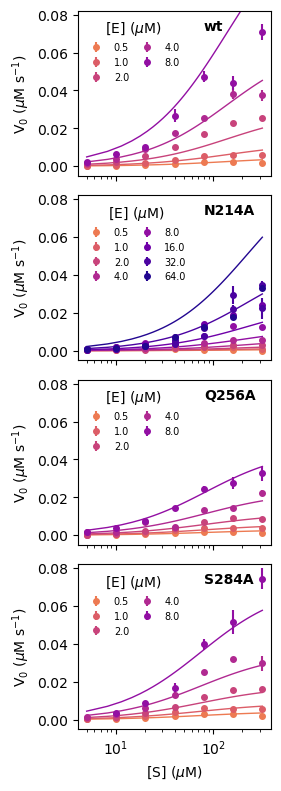

In [6]:
Z_star = 1.96 # 95% CI

S = np.linspace(ss.min(), ss.max(), 100)

fig, axes = plt.subplots(4, 1, figsize=(3,8), sharex=True)

print('\tk_cat (1/min)\t\tK_m (µM)\tK_d (µM)')
print('\t-------------\t\t--------\t--------')

for im, m in enumerate(mutants):
    
    ks = ks_s[im]

    ax = axes[im]
    ax.text(80, 0.072, m, weight="bold")

    # fit to dimer activity model, different enzyme conc for N214A
    if m == 'N214A':
        ps = n214a_ps
    else:
        ps = normal_ps
    
    s0s, p0s, v0s, v0errs = ks.get_set_v0s(ps, ss)
    
    # there is an issue with some fits failing
    # and the errors are set to zero -- discard these
    good = (v0errs != 0.0)
    s0s = s0s[good]
    p0s = p0s[good]
    v0s = v0s[good]
    v0errs = v0errs[good]

    # parameters: k_cat, K_m, K_d
    # note: divide by 20 to account for dilution in experiment
    popt, perr = fit_mm_dimer(v0s, s0s, p0s / 20.0, v0errs=v0errs)
    
    for i,p in enumerate(ps):
        s0s, _, v0s, v0errs = ks.get_set_v0s([p], ss)
        ax.errorbar(s0s, v0s, fmt='.', yerr=v0errs, c=set_color(p), markersize=8)

    for i,p in enumerate(ps):
        V_fit = mm_dimer( p / 20.0, S, *popt)
        #if m != 'N214A':
        ax.plot(S, V_fit, lw=1, c=set_color(p), label="_nolegend_")

    fmt_params = [m]
    for i in range(3):
        fmt_params.append(popt[i])
        fmt_params.append(perr[i] * Z_star)
        
    # convert 1/s to 1/min
    fmt_params[1] = float(fmt_params[1]) * 60.0  # kcat
    fmt_params[2] = float(fmt_params[2]) * 60.0  # error on kcat

    print('%s\t%.2f +/- %.3f\t%.1f +/- %.1f\t%.3f +/- %.3f' % tuple(fmt_params))

    ax.set_xscale('log')
    if im == 3:
        ax.set_xlabel('[S] ($\mu$M)')

    ax.set_ylim([-0.005, 0.082])
    ax.set_ylabel('V$_0$ ($\mu$M s$^{-1}$)')

    ax.legend(
        np.array(ps) / 20.0,
        title='[E] ($\mu$M)',
        fontsize=7,
        loc=2,
        frameon=False,
        ncol=2,
        columnspacing=0.8,
    )

print("\nErrors are a 95% confidence interval (Z=1.96) on the fit parameters.")

plt.tight_layout()
plt.savefig('figures/mm_dimer-linreg_error.pdf')
plt.show()

### vanilla Michaelis-Menten

	[E]	k_cat (1/min)	kcat/Km (1/µM-min)
	---	-------------	------------------
wt	0.50	0.28 +/- 0.105	0.0076 +/- 0.0069
wt	1.00	0.45 +/- 0.104	0.0079 +/- 0.0038
wt	2.00	1.02 +/- 0.125	0.0112 +/- 0.0022
wt	4.00	0.75 +/- 0.137	0.0099 +/- 0.0033
wt	8.00	0.67 +/- 0.217	0.0064 +/- 0.0031
N214A	0.50	0.07 +/- 0.046	0.0073 +/- 0.0171
N214A	1.00	0.12 +/- 0.064	0.0130 +/- 0.0304
N214A	2.00	0.12 +/- 0.022	0.0015 +/- 0.0005
N214A	4.00	0.10 +/- 0.015	0.0020 +/- 0.0006
N214A	8.00	0.12 +/- 0.021	0.0022 +/- 0.0008
N214A	16.00	0.14 +/- 0.040	0.0008 +/- 0.0003
N214A	32.00	0.11 +/- 0.075	0.0004 +/- 0.0002
N214A	64.00	0.08 +/- 0.038	0.0002 +/- 0.0000
Q256A	0.50	0.21 +/- 0.063	0.0076 +/- 0.0063
Q256A	1.00	0.29 +/- 0.059	0.0065 +/- 0.0030
Q256A	2.00	0.35 +/- 0.085	0.0050 +/- 0.0023
Q256A	4.00	0.46 +/- 0.200	0.0033 +/- 0.0019
Q256A	8.00	0.30 +/- 0.041	0.0043 +/- 0.0011
S284A	0.50	0.34 +/- 0.144	0.0130 +/- 0.0153
S284A	1.00	0.41 +/- 0.112	0.0110 +/- 0.0074
S284A	2.00	0.64 +/- 0.126	0.0083 +/- 0.0029
S284A	4.00	0

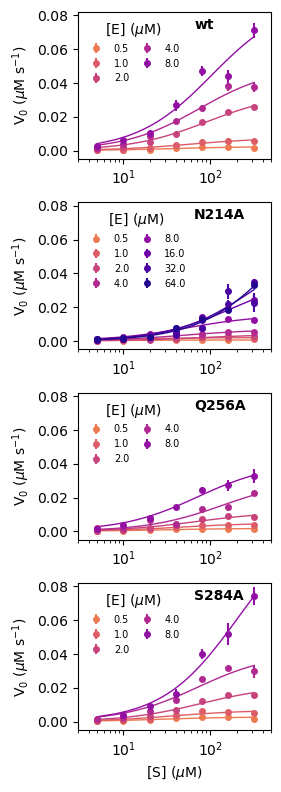

In [13]:
resulting_data = {m : [] for m in mutants}

fig, axes = plt.subplots(4, 1, figsize=(3,8))

print('\t[E]\tk_cat (1/min)\tkcat/Km (1/µM-min)')
print('\t---\t-------------\t------------------')

for im, m in enumerate(mutants):
    
    ks = ks_s[im]

    # fit to dimer activity model, different enzyme conc for N214A
    if m == 'N214A':
        ps = n214a_ps
    else:
        ps = normal_ps

    axes[im].text(65, 0.072, m, weight="bold")
    
    for p in ps:

        # parameters: k_cat, K_m, K_d
        # note: divide by 20 to account for dilution in experiment
        s0s, _, v0s, v0errs = ks.get_set_v0s([p], ss)

        # there is an issue with some fits failing
        # and the errors are set to zero -- discard these

        good = (v0errs != 0.0)

        if np.sum(good) == 0:
            print(f"no good data for mutant {m}, [E]={p}")
            #bad = (v0errs == 0.0)
            v0s[~good] = 0.0
            v0errs[~good] = np.inf
        else:
            s0s = s0s[good]
            v0s = v0s[good]
            v0errs = v0errs[good]

        popt, perr = fit_mm(v0s, s0s, p / 20.0, v0errs=None)
        V_fit = mm(p / 20.0, S, *popt)
        
        axes[im].errorbar(s0s, v0s, fmt='.', yerr=v0errs, c=set_color(p), markersize=8)
        axes[im].plot(S, V_fit, lw=1, c=set_color(p), label="_nolegend_")

        fmt_params = [m, p/20.0]
        for i in range(2):
            fmt_params.append(popt[i])
            fmt_params.append(perr[i] * Z_star)

        # convert 1/s to 1/min
        fmt_params[2] = float(fmt_params[2]) * 60.0  # kcat
        fmt_params[3] = float(fmt_params[3]) * 60.0  # error on kcat
        fmt_params[4] = float(fmt_params[4]) * 60.0  # kcat/Km
        fmt_params[5] = float(fmt_params[5]) * 60.0  # error on kcat/Km

        print('%s\t%.2f\t%.2f +/- %.3f\t%.4f +/- %.4f' % tuple(fmt_params))
        resulting_data[m].append(
            {
                "[E] (µM)": fmt_params[1],
                "kcat (1/min)": fmt_params[2],
                "CI95(kcat) (1/min)": fmt_params[3],
                "kcat/Km (1/min 1/µM)": fmt_params[4],
                "CI95(kcat/Km) (1/min 1/µM)": fmt_params[5],
            }
        )

    axes[im].set_xscale('log')
    if im == 3:
        axes[im].set_xlabel('[S] ($\mu$M)')

    axes[im].set_ylim([-0.005, 0.082])
    axes[im].set_ylabel('V$_0$ ($\mu$M s$^{-1}$)')
    axes[im].set_xlim([3, 500])

    axes[im].legend(
        np.array(ps) / 20.0,
        title='[E] ($\mu$M)',
        fontsize=7,
        loc=2,
        frameon=False,
        ncol=2,
        columnspacing=0.8,
    )

print("\nErrors are a 95% confidence interval (Z=1.96) on the fit parameters.")

plt.tight_layout()
plt.savefig('figures/mm_each_concentration_independently.pdf')
plt.show()

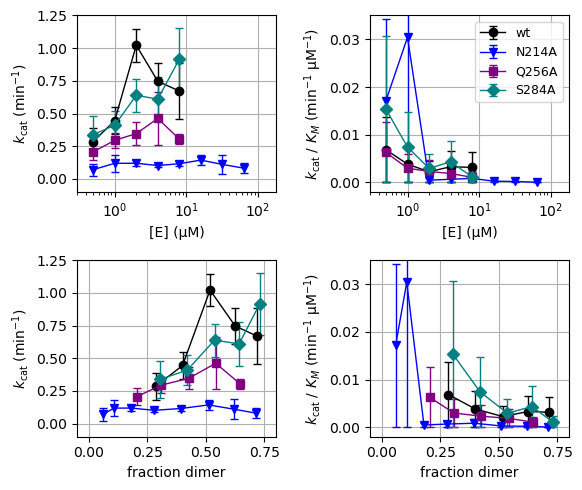

In [8]:
markersize = 6

percent_dimer = lambda E_0, K_d : 1.0 - ( np.sqrt( 8.0*E_0 / K_d + 1 ) - 1 ) / (4.0 * E_0 / K_d)

plt.figure(figsize=(6,5))

ax_lt = plt.subplot(221)
ax_ll = plt.subplot(223)

for im,mutant in enumerate(mutants):
    df = pd.DataFrame(resulting_data[mutant])
    pDimer = percent_dimer(df["[E] (µM)"], KDs[im])
    ax_lt.errorbar(df["[E] (µM)"], df["kcat (1/min)"], yerr=df["CI95(kcat) (1/min)"], color=mutant_colors[im], marker=mutant_markers[im], markersize=markersize, lw=1, capsize=3)
    ax_ll.errorbar(pDimer, df["kcat (1/min)"], yerr=df["CI95(kcat) (1/min)"], color=mutant_colors[im], marker=mutant_markers[im], markersize=markersize, lw=1, capsize=3)

for ax in [ax_lt, ax_ll]:
    ax.set_ylim([-.1, 1.25])
    ax.set_ylabel("$k_\mathrm{cat}$ (min$^{-1}$)")
    ax.grid()

# ---------

ax_rt = plt.subplot(222)
ax_rl = plt.subplot(224)

for im,mutant in enumerate(mutants):
    df = pd.DataFrame(resulting_data[mutant])

    # convert to per-minute
    specificity = df["CI95(kcat/Km) (1/min 1/µM)"]
    error = df["CI95(kcat/Km) (1/min 1/µM)"]
    
    pDimer = percent_dimer(df["[E] (µM)"], KDs[im])
    ax_rt.errorbar(df["[E] (µM)"], specificity, yerr=error, color=mutant_colors[im], marker=mutant_markers[im], markersize=markersize, lw=1, capsize=3)
    ax_rl.errorbar(pDimer, specificity, yerr=error, color=mutant_colors[im], marker=mutant_markers[im], markersize=markersize, lw=1, capsize=3)

ax_rt.set_xscale("log")
ax_rt.set_xlim([0.1, 100])
ax_rt.set_xlabel("[E] (µM)")

for ax in [ax_rt, ax_rl]:
    ax.set_ylabel("$k_\mathrm{cat}$ / $K_M$ (min$^{-1}$ µM$^{-1}$)")
    ax.set_ylim([-0.002, .035])
    ax.grid()

# ---------

ax_rt.legend(mutants, fontsize=9)

for ax in [ax_lt, ax_rt]:
    ax.set_xscale("log")
    ax.set_xlim([0.3, 180])
    ax.set_xlabel("[E] (µM)")

for ax in [ax_ll, ax_rl]:
    ax.set_xlim([-0.05, 0.8])
    ax.set_xlabel("fraction dimer")

plt.tight_layout()
plt.savefig('figures/mm_each_concentration_independently-mm_parameters.pdf')
plt.show()

In [9]:
# write v0 data to excel
with pd.ExcelWriter('fit_michaelis-menten_parameters.xlsx') as writer:
    for mutant in mutants:
        df = pd.DataFrame(resulting_data[mutant])
        df.to_excel(writer, sheet_name=mutant, index=False)

## "third order" model

$$
2M + S \rightleftharpoons DS \to D + P
$$
with $K_M$, $k_\mathrm{cat}$, but second order in protein

	k_cat (1/min)		K_m (µM^2)
	-------------		--------
wt	1.63 +/- 0.483	1030.7 +/- 819.0
N214A	0.11 +/- 0.063	9892.4 +/- 13953.2
Q256A	0.81 +/- 0.177	927.8 +/- 563.7
S284A	2.11 +/- 0.607	2241.2 +/- 1427.4

Errors are a 95% confidence interval (Z=1.96) on the fit parameters.


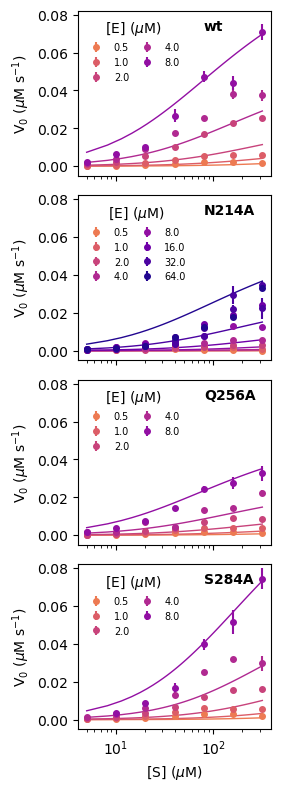

In [10]:
fig, axes = plt.subplots(4, 1, figsize=(3,8), sharex=True)

print('\tk_cat (1/min)\t\tK_m (µM^2)')
print('\t-------------\t\t--------')

for im, m in enumerate(mutants):
    
    ks = ks_s[im]

    ax = axes[im]
    ax.text(80, 0.072, m, weight="bold")

    # fit to dimer activity model, different enzyme conc for N214A
    if m == 'N214A':
        ps = n214a_ps
    else:
        ps = normal_ps
    
    s0s, p0s, v0s, v0errs = ks.get_set_v0s(ps, ss)
    
    # there is an issue with some fits failing
    # and the errors are set to zero -- discard these
    good = (v0errs != 0.0)
    s0s = s0s[good]
    p0s = p0s[good]
    v0s = v0s[good]
    v0errs = v0errs[good]

    # parameters: k_cat, K_m, K_d
    # note: divide by 20 to account for dilution in experiment
    popt, perr = fit_mm_third_order(v0s, s0s, p0s / 20.0, v0errs=None)
    
    for i,p in enumerate(ps):
        s0s, _, v0s, v0errs = ks.get_set_v0s([p], ss)
        ax.errorbar(s0s, v0s, fmt='.', yerr=v0errs, c=set_color(p), markersize=8)

    for i,p in enumerate(ps):
        V_fit = mm_third_order( p / 20.0, S, *popt)
        #V_fit = mm_third_order( p / 20.0, S, *[0.02, 2000.0])
        #if m != 'N214A':
        ax.plot(S, V_fit, lw=1, c=set_color(p), label="_nolegend_")

    fmt_params = [m]
    for i in range(2):
        fmt_params.append(popt[i])
        fmt_params.append(perr[i] * Z_star)
        
    # convert 1/s to 1/min
    fmt_params[1] = float(fmt_params[1]) * 60.0  # kcat
    fmt_params[2] = float(fmt_params[2]) * 60.0  # error on kcat

    print('%s\t%.2f +/- %.3f\t%.1f +/- %.1f' % tuple(fmt_params))

    ax.set_xscale('log')
    if im == 3:
        ax.set_xlabel('[S] ($\mu$M)')

    ax.set_ylim([-0.005, 0.082])
    ax.set_ylabel('V$_0$ ($\mu$M s$^{-1}$)')

    ax.legend(
        np.array(ps) / 20.0,
        title='[E] ($\mu$M)',
        fontsize=7,
        loc=2,
        frameon=False,
        ncol=2,
        columnspacing=0.8,
    )

print("\nErrors are a 95% confidence interval (Z=1.96) on the fit parameters.")

plt.tight_layout()
plt.savefig('figures/mm_third_order.pdf')
plt.show()

### plot of V0 / [E] vs [E]

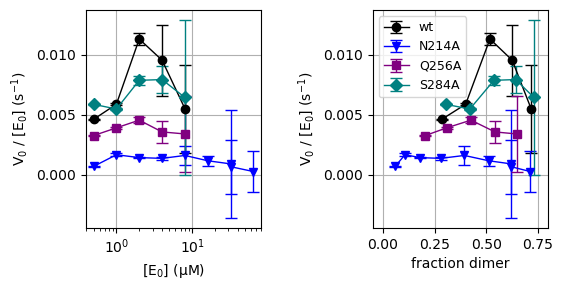

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(6,3))

s = 160.0

for im, m in enumerate(mutants):
    
    ks = ks_s[im]

    # fit to dimer activity model, different enzyme conc for N214A
    if m == 'N214A':
        ps = n214a_ps
    else:
        ps = normal_ps

    # parameters: k_cat, K_m, K_d
    # note: divide by 20 to account for dilution in experiment
    s0s, p0s, v0s, v0errs = ks.get_set_v0s(ps, [s])

    # there is an issue with some fits failing
    # and the errors are set to zero -- discard these
    good = (v0errs != 0.0)

    if np.sum(good) == 0:
        print(f"no good data for mutant {m}, [E]={p}")
        v0s[~good] = 0.0
        v0errs[~good] = np.inf
    else:
        s0s = s0s[good]
        v0s = v0s[good]
        p0s = p0s[good]
        v0errs = v0errs[good]
    
    corrected_p0s = p0s / 20.0
    pDimer = percent_dimer(corrected_p0s, KDs[im])

    axes[0].errorbar(corrected_p0s, v0s / corrected_p0s, yerr=v0errs,  color=mutant_colors[im], marker=mutant_markers[im], markersize=markersize, capsize=4, lw=1)
    axes[1].errorbar(pDimer, v0s / corrected_p0s,  yerr=v0errs,  color=mutant_colors[im], marker=mutant_markers[im], markersize=markersize, capsize=4, lw=1)

for im in [0, 1]:
    axes[im].set_ylabel('V$_0$ / [E$_0$] (s$^{-1}$)')
    axes[im].grid()
    #axes[im].set_ylim([-0.001, 0.014])

axes[0].set_xlabel('[E$_0$] (µM)')
axes[0].set_xscale("log")

axes[1].set_xlabel('fraction dimer')
axes[1].set_xlim([-.05, .8])

axes[1].legend(
    mutants,
    fontsize=9,
    loc=2,
    frameon=True,
    ncol=1,
    columnspacing=0.8,
)

plt.tight_layout()
#plt.savefig('figures/*.pdf')
plt.show()